In [1]:
# ============================================================
# 1. Imports
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from scipy.stats import ttest_ind
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# ============================================================
# 2. Load Excel file
# ============================================================

file_path = "Fina_SHIMP Data.xlsx"

raw = pd.read_excel(file_path, sheet_name="Sheet1", header=None)

raw.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,NaN,NaN,Week 1: VOR Gain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Demographic Info,NaN,HIMP Run 1,NaN,NaN,NaN,NaN,NaN,HIMP Run 2,NaN,...,NaN,NaN,NaN,NaN,SHIMP Run 2,NaN,NaN,NaN,NaN,NaN
2,ID,Age/Sex,RL,LL,RA,LP,LA,RP,RL,LL,...,RA,LP,LA,RP,RL,LL,RA,LP,LA,RP
3,VSHIMP098,25/F,1.13,1.15,1.43,1.98,0.87,1.06,1.14,1.14,...,1.47,1.5,0.77,1.03,1.2,1.07,1.23,1.14,0.99,1.65
4,VSHIMP997,24/F,1.16,1.15,1.23,1.43,1.11,0.99,1.12,1.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ============================================================
# 3. Extract HIMP-only data
# ============================================================

canals = ["RL", "LL", "RA", "LP", "LA", "RP"]

himp_blocks = {
    ("W1", "Right"): range(2, 8),     # Week 1 HIMP Run 1 - Right camera
    ("W1", "Left"): range(8, 14),     # Week 1 HIMP Run 2 - Left camera
    ("W2", "Right"): range(26, 32),   # Week 2 HIMP Run 1 - Right camera
    ("W2", "Left"): range(32, 38),    # Week 2 HIMP Run 2 - Left camera
}

records = []

for i in range(3, len(raw)):
    participant_id = raw.iloc[i, 0]
    age_sex = raw.iloc[i, 1]

    if pd.isna(participant_id):
        continue

    for (week, camera_side), cols in himp_blocks.items():
        for canal, col in zip(canals, cols):
            gain = raw.iloc[i, col]

            if pd.notna(gain):
                records.append({
                    "participant_id": participant_id,
                    "age_sex": age_sex,
                    "week": week,
                    "camera_side": camera_side,
                    "canal": canal,
                    "raw_himp_gain": gain
                })

df_himp = pd.DataFrame(records)

df_himp["raw_himp_gain"] = pd.to_numeric(
    df_himp["raw_himp_gain"],
    errors="coerce"
)

df_himp = df_himp.dropna(subset=["raw_himp_gain"]).copy()

df_himp.head()

,participant_id,age_sex,week,camera_side,canal,raw_himp_gain
0,VSHIMP098,25/F,W1,Right,RL,1.13
1,VSHIMP098,25/F,W1,Right,LL,1.15
2,VSHIMP098,25/F,W1,Right,RA,1.43
3,VSHIMP098,25/F,W1,Right,LP,1.98
4,VSHIMP098,25/F,W1,Right,LA,0.87


In [4]:
# ============================================================
# 4. Add clinical features
# ============================================================

df_himp["canal_type"] = np.where(
    df_himp["canal"].isin(["RL", "LL"]),
    "Horizontal",
    "Vertical"
)

df_himp["expected_inflated_pair"] = np.where(
    ((df_himp["camera_side"] == "Right") & (df_himp["canal"].isin(["RA", "LP"]))) |
    ((df_himp["camera_side"] == "Left") & (df_himp["canal"].isin(["LA", "RP"]))),
    1,
    0
)

df_himp.head()

,participant_id,age_sex,week,camera_side,canal,raw_himp_gain,canal_type,expected_inflated_pair
0,VSHIMP098,25/F,W1,Right,RL,1.13,Horizontal,0
1,VSHIMP098,25/F,W1,Right,LL,1.15,Horizontal,0
2,VSHIMP098,25/F,W1,Right,RA,1.43,Vertical,1
3,VSHIMP098,25/F,W1,Right,LP,1.98,Vertical,1
4,VSHIMP098,25/F,W1,Right,LA,0.87,Vertical,0


In [5]:
# ============================================================
# 5. Basic data checks
# ============================================================

print("Shape:", df_himp.shape)
print(df_himp.isna().sum())

df_himp.groupby(["week", "camera_side", "canal"])["raw_himp_gain"].agg(
    count="count",
    mean="mean",
    std="std",
    min="min",
    max="max"
).reset_index()

Shape: (420, 8)
participant_id            0
age_sex                   0
week                      0
camera_side               0
canal                     0
raw_himp_gain             0
canal_type                0
expected_inflated_pair    0
dtype: int64


,week,camera_side,canal,count,mean,std,min,max
0,W1,Left,LA,20,1.422000,0.187942,1.08,1.90
1,W1,Left,LL,20,1.118500,0.062008,0.97,1.23
2,W1,Left,LP,20,1.231500,0.103429,1.10,1.48
3,W1,Left,RA,20,1.222500,0.111633,1.05,1.42
4,W1,Left,RL,20,1.076500,0.074993,0.93,1.21
5,W1,Left,RP,20,1.484000,0.223522,1.04,1.87
6,W1,Right,LA,20,1.242500,0.295152,0.87,2.11
7,W1,Right,LL,20,1.058500,0.098263,0.85,1.22
8,W1,Right,LP,20,1.370000,0.174868,1.07,1.98
9,W1,Right,RA,20,1.420500,0.178811,1.07,1.68


In [6]:
# ============================================================
# 6. Confirm Week 1 vs Week 2 stability
# ============================================================

w1 = df_himp[df_himp["week"] == "W1"]["raw_himp_gain"]
w2 = df_himp[df_himp["week"] == "W2"]["raw_himp_gain"]

t_stat, p_val = ttest_ind(w1, w2, nan_policy="omit")

print("T-statistic:", t_stat)
print("P-value:", p_val)

if p_val > 0.05:
    print("No significant week effect detected. Week will not be used in correction pattern.")
else:
    print("Week effect detected. Review whether acquisition/session effects should be modeled.")

T-statistic: 1.018689560844657
P-value: 0.3089396057588644
No significant week effect detected. Week will not be used in correction pattern.


In [11]:
# ============================================================
# 7. Create paired Right-vs-Left comparison
# ============================================================

paired = df_himp.pivot_table(
    index=["participant_id", "week", "canal"],
    columns="camera_side",
    values="raw_himp_gain",
    aggfunc="mean"
).reset_index()

paired = paired.dropna(subset=["Right", "Left"]).copy()

paired.head(10)

camera_side,participant_id,week,canal,Left,Right
0,VSHIMP-D002,W1,LA,1.48,1.44
1,VSHIMP-D002,W1,LL,1.08,1.02
2,VSHIMP-D002,W1,LP,1.13,1.47
3,VSHIMP-D002,W1,RA,1.15,1.59
4,VSHIMP-D002,W1,RL,1.12,1.06
5,VSHIMP-D002,W1,RP,1.72,1.31
6,VSHIMP002,W1,LA,1.39,1.13
7,VSHIMP002,W1,LL,1.13,1.09
8,VSHIMP002,W1,LP,1.27,1.35
9,VSHIMP002,W1,RA,1.31,1.30


In [10]:
# ============================================================
# 8. Calculate percentage inflation from known biased pairs
# ============================================================

inflation_records = []

for _, row in paired.iterrows():
    participant_id = row["participant_id"]
    week = row["week"]
    canal = row["canal"]
    right_gain = row["Right"]
    left_gain = row["Left"]

    # Known pattern from paper/experiment:
    # Right camera inflates RA and LP
    if canal in ["RA", "LP"]:
        inflated_camera = "Right"
        reference_camera = "Left"
        inflated_gain = right_gain
        reference_gain = left_gain

    # Left camera inflates LA and RP
    elif canal in ["LA", "RP"]:
        inflated_camera = "Left"
        reference_camera = "Right"
        inflated_gain = left_gain
        reference_gain = right_gain

    # Horizontal canals are not used to train vertical inflation pattern
    else:
        continue

    if pd.isna(inflated_gain) or pd.isna(reference_gain):
        continue

    if reference_gain <= 0:
        continue

    inflation_pct = (inflated_gain - reference_gain) / reference_gain

    inflation_records.append({
        "participant_id": participant_id,
        "week": week,
        "canal": canal,
        "inflated_camera": inflated_camera,
        "reference_camera": reference_camera,
        "inflated_gain": inflated_gain,
        "reference_gain": reference_gain,
        "inflation_pct": inflation_pct
    })

inflation_df = pd.DataFrame(inflation_records)

inflation_df.head()

,participant_id,week,canal,inflated_camera,reference_camera,inflated_gain,reference_gain,inflation_pct
0,VSHIMP-D002,W1,LA,Left,Right,1.48,1.44,0.027778
1,VSHIMP-D002,W1,LP,Right,Left,1.47,1.13,0.300885
2,VSHIMP-D002,W1,RA,Right,Left,1.59,1.15,0.382609
3,VSHIMP-D002,W1,RP,Left,Right,1.72,1.31,0.312977
4,VSHIMP002,W1,LA,Left,Right,1.39,1.13,0.230088


In [12]:
# ============================================================
# 9. Remove impossible/negative inflation patterns if needed
# ============================================================

# Keep original for audit
inflation_df["inflation_pct_raw"] = inflation_df["inflation_pct"]

# Optional: camera inflation should not be negative.
# If negative values happen due to measurement variability, set them to 0.
inflation_df["inflation_pct"] = inflation_df["inflation_pct"].clip(lower=0)

inflation_df.head()

,participant_id,week,canal,inflated_camera,reference_camera,inflated_gain,reference_gain,inflation_pct,inflation_pct_raw
0,VSHIMP-D002,W1,LA,Left,Right,1.48,1.44,0.027778,0.027778
1,VSHIMP-D002,W1,LP,Right,Left,1.47,1.13,0.300885,0.300885
2,VSHIMP-D002,W1,RA,Right,Left,1.59,1.15,0.382609,0.382609
3,VSHIMP-D002,W1,RP,Left,Right,1.72,1.31,0.312977,0.312977
4,VSHIMP002,W1,LA,Left,Right,1.39,1.13,0.230088,0.230088


In [13]:
# ============================================================
# 10. Learn pattern percentage by canal-camera pair
# ============================================================

pattern_table = (
    inflation_df
    .groupby(["inflated_camera", "canal"])
    .agg(
        learned_inflation_pct=("inflation_pct", "mean"),
        median_inflation_pct=("inflation_pct", "median"),
        std_inflation_pct=("inflation_pct", "std"),
        min_inflation_pct=("inflation_pct", "min"),
        max_inflation_pct=("inflation_pct", "max"),
        n=("inflation_pct", "count")
    )
    .reset_index()
)

pattern_table["learned_inflation_pct_display"] = (
    pattern_table["learned_inflation_pct"] * 100
)

pattern_table["median_inflation_pct_display"] = (
    pattern_table["median_inflation_pct"] * 100
)

pattern_table

,inflated_camera,canal,learned_inflation_pct,median_inflation_pct,std_inflation_pct,min_inflation_pct,max_inflation_pct,n,learned_inflation_pct_display,median_inflation_pct_display
0,Left,LA,0.249315,0.273684,0.182717,0.0,0.573770,35,24.931500,27.368421
1,Left,RP,0.229749,0.167939,0.194946,0.0,0.619048,35,22.974941,16.793893
2,Right,LP,0.128865,0.097015,0.139197,0.0,0.650000,35,12.886489,9.701493
3,Right,RA,0.190504,0.152542,0.193473,0.0,0.975904,35,19.050423,15.254237


In [14]:
# ============================================================
# 11. Apply learned pattern back to healthy inflated data
# ============================================================

inflation_df = inflation_df.merge(
    pattern_table[["inflated_camera", "canal", "learned_inflation_pct"]],
    on=["inflated_camera", "canal"],
    how="left"
)

inflation_df["corrected_gain"] = (
    inflation_df["inflated_gain"] / (1 + inflation_df["learned_inflation_pct"])
)

inflation_df["correction_amount"] = (
    inflation_df["inflated_gain"] - inflation_df["corrected_gain"]
)

inflation_df.head()

,participant_id,week,canal,inflated_camera,reference_camera,inflated_gain,reference_gain,inflation_pct,inflation_pct_raw,learned_inflation_pct,corrected_gain,correction_amount
0,VSHIMP-D002,W1,LA,Left,Right,1.48,1.44,0.027778,0.027778,0.249315,1.184649,0.295351
1,VSHIMP-D002,W1,LP,Right,Left,1.47,1.13,0.300885,0.300885,0.128865,1.302193,0.167807
2,VSHIMP-D002,W1,RA,Right,Left,1.59,1.15,0.382609,0.382609,0.190504,1.335569,0.254431
3,VSHIMP-D002,W1,RP,Left,Right,1.72,1.31,0.312977,0.312977,0.229749,1.398659,0.321341
4,VSHIMP002,W1,LA,Left,Right,1.39,1.13,0.230088,0.230088,0.249315,1.112610,0.277390


In [15]:
# ============================================================
# 12. Evaluate correction against paired reference value
# ============================================================

before_mae = mean_absolute_error(
    inflation_df["reference_gain"],
    inflation_df["inflated_gain"]
)

after_mae = mean_absolute_error(
    inflation_df["reference_gain"],
    inflation_df["corrected_gain"]
)

before_rmse = mean_squared_error(
    inflation_df["reference_gain"],
    inflation_df["inflated_gain"]
) ** 0.5

after_rmse = mean_squared_error(
    inflation_df["reference_gain"],
    inflation_df["corrected_gain"]
) ** 0.5

improvement_pct = (before_mae - after_mae) / before_mae * 100

print("Before correction MAE vs reference:", before_mae)
print("After correction MAE vs reference:", after_mae)
print("Before correction RMSE vs reference:", before_rmse)
print("After correction RMSE vs reference:", after_rmse)
print("Improvement %:", improvement_pct)

Before correction MAE vs reference: 0.252
After correction MAE vs reference: 0.16446198494796216
Before correction RMSE vs reference: 0.31246942707590264
After correction RMSE vs reference: 0.21949499993469354
Improvement %: 34.737307560332475


In [16]:
# ============================================================
# 13. Canal-level evaluation
# ============================================================

canal_eval = inflation_df.groupby(["inflated_camera", "canal"]).apply(
    lambda x: pd.Series({
        "inflated_mean_gain": x["inflated_gain"].mean(),
        "reference_mean_gain": x["reference_gain"].mean(),
        "corrected_mean_gain": x["corrected_gain"].mean(),
        "learned_inflation_pct": x["learned_inflation_pct"].mean(),
        "learned_inflation_pct_display": x["learned_inflation_pct"].mean() * 100,
        "before_mae_vs_reference": np.mean(np.abs(x["inflated_gain"] - x["reference_gain"])),
        "after_mae_vs_reference": np.mean(np.abs(x["corrected_gain"] - x["reference_gain"])),
        "n": len(x)
    })
).reset_index()

canal_eval

,inflated_camera,canal,inflated_mean_gain,reference_mean_gain,corrected_mean_gain,learned_inflation_pct,learned_inflation_pct_display,before_mae_vs_reference,after_mae_vs_reference,n
0,Left,LA,1.424286,1.199429,1.140053,0.249315,24.931500,0.314571,0.195710,35.0
1,Left,RP,1.474857,1.231143,1.199315,0.229749,22.974941,0.289429,0.189969,35.0
2,Right,LP,1.358000,1.231714,1.202978,0.128865,12.886489,0.172000,0.129196,35.0
3,Right,RA,1.416571,1.215429,1.189892,0.190504,19.050423,0.232000,0.142973,35.0


In [17]:
# ============================================================
# 14. Pattern table dictionary for app/new patients
# ============================================================

pattern_lookup = {
    (row["inflated_camera"], row["canal"]): row["learned_inflation_pct"]
    for _, row in pattern_table.iterrows()
}

pattern_lookup

{('Left', 'LA'): 0.24931499848944944,
 ('Left', 'RP'): 0.22974941076905714,
 ('Right', 'LP'): 0.12886489202867846,
 ('Right', 'RA'): 0.19050423276050205}

In [18]:
# ============================================================
# 15. New patient correction function
# ============================================================

def correct_new_himp_gain(raw_gain, camera_side, canal, pattern_lookup):
    """
    Pattern-based proportional HIMP correction.

    It does NOT force the value toward 1.0.
    It removes learned camera-placement inflation proportionally.

    Formula:
        corrected_gain = raw_gain / (1 + learned_inflation_pct)
    """

    key = (camera_side, canal)

    if key not in pattern_lookup:
        return {
            "raw_gain": raw_gain,
            "camera_side": camera_side,
            "canal": canal,
            "canal_type": "Horizontal" if canal in ["RL", "LL"] else "Vertical",
            "learned_inflation_pct": 0.0,
            "learned_inflation_pct_display": 0.0,
            "corrected_gain": raw_gain,
            "correction_amount": 0.0,
            "pattern_found": False,
            "message": "No learned inflation pattern for this canal-camera pair. No correction applied."
        }

    learned_inflation_pct = pattern_lookup[key]
    learned_inflation_pct = max(learned_inflation_pct, 0)

    corrected_gain = raw_gain / (1 + learned_inflation_pct)
    correction_amount = raw_gain - corrected_gain

    return {
        "raw_gain": raw_gain,
        "camera_side": camera_side,
        "canal": canal,
        "canal_type": "Horizontal" if canal in ["RL", "LL"] else "Vertical",
        "learned_inflation_pct": learned_inflation_pct,
        "learned_inflation_pct_display": learned_inflation_pct * 100,
        "corrected_gain": corrected_gain,
        "correction_amount": correction_amount,
        "pattern_found": True,
        "message": "Corrected using learned proportional camera-placement inflation pattern."
    }

In [19]:
# ============================================================
# 16. Test examples
# ============================================================

# Example you wanted:
# If Right camera + RA has learned inflation, 0.80 should be corrected downward.
test_1 = correct_new_himp_gain(
    raw_gain=0.80,
    camera_side="Right",
    canal="RA",
    pattern_lookup=pattern_lookup
)

test_1

{'raw_gain': 0.8,
 'camera_side': 'Right',
 'canal': 'RA',
 'canal_type': 'Vertical',
 'learned_inflation_pct': 0.19050423276050205,
 'learned_inflation_pct_display': 19.050423276050203,
 'corrected_gain': 0.6719841710642107,
 'correction_amount': 0.12801582893578933,
 'pattern_found': True,
 'message': 'Corrected using learned proportional camera-placement inflation pattern.'}

In [20]:
test_2 = correct_new_himp_gain(
    raw_gain=1.40,
    camera_side="Right",
    canal="RA",
    pattern_lookup=pattern_lookup
)

test_2

{'raw_gain': 1.4,
 'camera_side': 'Right',
 'canal': 'RA',
 'canal_type': 'Vertical',
 'learned_inflation_pct': 0.19050423276050205,
 'learned_inflation_pct_display': 19.050423276050203,
 'corrected_gain': 1.1759722993623685,
 'correction_amount': 0.22402770063763144,
 'pattern_found': True,
 'message': 'Corrected using learned proportional camera-placement inflation pattern.'}

In [21]:
test_3 = correct_new_himp_gain(
    raw_gain=0.80,
    camera_side="Left",
    canal="LA",
    pattern_lookup=pattern_lookup
)

test_3

{'raw_gain': 0.8,
 'camera_side': 'Left',
 'canal': 'LA',
 'canal_type': 'Vertical',
 'learned_inflation_pct': 0.24931499848944944,
 'learned_inflation_pct_display': 24.931499848944945,
 'corrected_gain': 0.6403509130741907,
 'correction_amount': 0.15964908692580937,
 'pattern_found': True,
 'message': 'Corrected using learned proportional camera-placement inflation pattern.'}

In [22]:
test_4 = correct_new_himp_gain(
    raw_gain=1.05,
    camera_side="Right",
    canal="RL",
    pattern_lookup=pattern_lookup
)

test_4

{'raw_gain': 1.05,
 'camera_side': 'Right',
 'canal': 'RL',
 'canal_type': 'Horizontal',
 'learned_inflation_pct': 0.0,
 'learned_inflation_pct_display': 0.0,
 'corrected_gain': 1.05,
 'correction_amount': 0.0,
 'pattern_found': False,
 'message': 'No learned inflation pattern for this canal-camera pair. No correction applied.'}

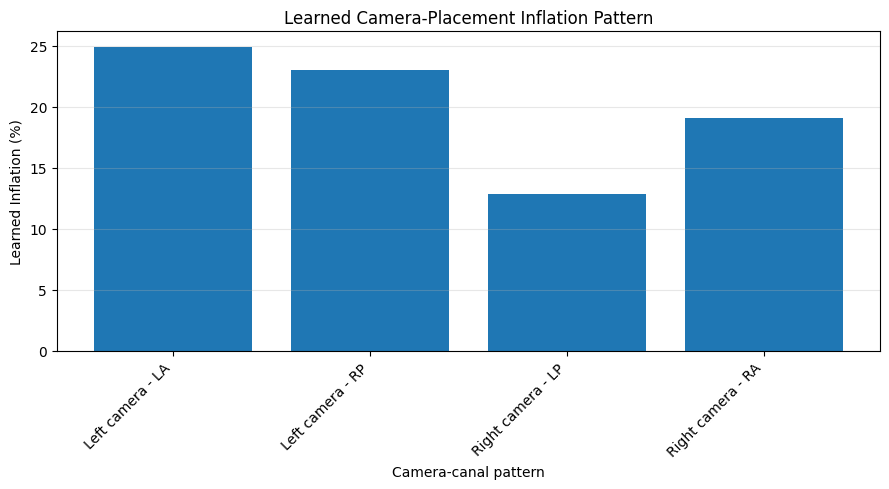

In [23]:
# ============================================================
# 17. Plot learned inflation percentage by canal-camera pattern
# ============================================================

plot_df = pattern_table.copy()
plot_df["label"] = plot_df["inflated_camera"] + " camera - " + plot_df["canal"]

plt.figure(figsize=(9, 5))

plt.bar(
    plot_df["label"],
    plot_df["learned_inflation_pct_display"]
)

plt.ylabel("Learned Inflation (%)")
plt.xlabel("Camera-canal pattern")
plt.title("Learned Camera-Placement Inflation Pattern")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

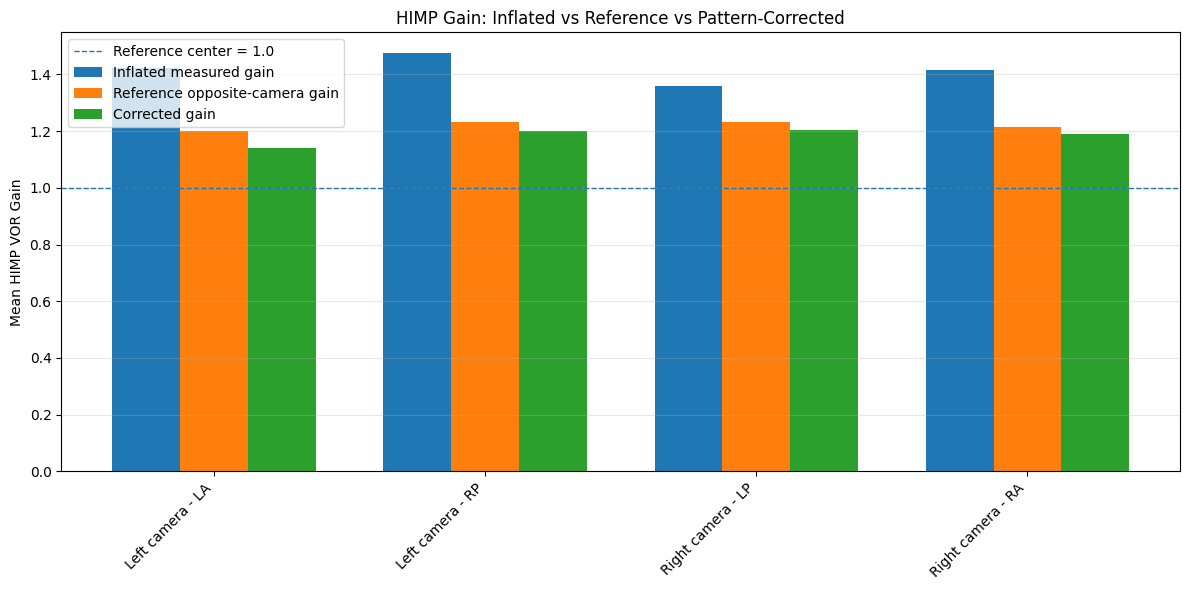

In [24]:
# ============================================================
# 18. Plot before, reference, and corrected gain
# ============================================================

plot_eval = canal_eval.copy()
plot_eval["label"] = plot_eval["inflated_camera"] + " camera - " + plot_eval["canal"]

x = np.arange(len(plot_eval))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    plot_eval["inflated_mean_gain"],
    width,
    label="Inflated measured gain"
)

plt.bar(
    x,
    plot_eval["reference_mean_gain"],
    width,
    label="Reference opposite-camera gain"
)

plt.bar(
    x + width,
    plot_eval["corrected_mean_gain"],
    width,
    label="Corrected gain"
)

plt.axhline(1.0, linestyle="--", linewidth=1, label="Reference center = 1.0")

plt.xticks(x, plot_eval["label"], rotation=45, ha="right")
plt.ylabel("Mean HIMP VOR Gain")
plt.title("HIMP Gain: Inflated vs Reference vs Pattern-Corrected")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# 19. Save model bundle for Streamlit
# ============================================================

model_bundle = {
    "model_type": "pattern_percentage_calibration",
    "pattern_table": pattern_table,
    "pattern_lookup": pattern_lookup,
    "formula": "corrected_gain = raw_gain / (1 + learned_inflation_pct)",
    "inflated_patterns": {
        "Right": ["RA", "LP"],
        "Left": ["LA", "RP"]
    },
    "notes": (
        "Trained on healthy-subject HIMP data. "
        "Learns proportional camera-placement inflation pattern. "
        "Does not diagnose vestibular disease."
    )
}

joblib.dump(model_bundle, "himp_pattern_calibration_model.pkl")

print("Saved model bundle: himp_pattern_calibration_model.pkl")

Saved model bundle: himp_pattern_calibration_model.pkl
